# Credit Card Fraud Detection using Machine Learning

Author: Vishal Kumar Roy

Models Used:
- Logistic Regression
- Random Forest
- XGBoost

Libraries:
- Pandas
- NumPy
- Scikit-learn
- XGBoost
- Imbalanced-learn

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE



from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [2]:
df = pd.read_csv("../data/creditcard.csv")

In [3]:
df.head(200)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,128.0,1.239495,-0.182609,0.155058,-0.928892,-0.746227,-1.235608,-0.061695,-0.125223,0.984938,...,0.146077,0.481119,-0.140019,0.538261,0.710720,-0.621382,0.036867,0.010963,8.80,0
196,130.0,-0.485238,0.658497,1.949967,1.249695,0.426410,0.231513,0.585115,0.029163,-0.520297,...,0.007290,0.328244,-0.232563,0.225572,0.025892,-0.247395,-0.025381,-0.118565,5.97,0
197,130.0,1.353283,-0.694900,0.970826,-0.426559,-1.417263,-0.505710,-0.932069,-0.083957,-0.224208,...,0.284341,0.993434,-0.164893,0.474257,0.623848,-0.006750,0.046026,0.022043,15.93,0
198,131.0,-1.007391,1.261943,1.207203,1.307575,0.153211,0.062291,0.508647,0.079447,-0.395211,...,0.039150,0.411661,-0.080320,0.121235,-0.133000,-0.303177,-0.463913,-0.164157,10.00,0


In [4]:
df["Class"].value_counts()

0    284315
1       492
Name: Class, dtype: int64

In [5]:
X = df.drop("Class" , axis =1 )

In [6]:
y =df["Class"]

In [7]:
X_train , X_test , y_train, y_test = train_test_split(X , y ,  test_size = 0.2 , random_state = 42)

In [8]:
smote = SMOTE( random_state = 42)

X_train_smote , y_train_smote = smote.fit_resample(
    X_train, 
    y_train
)

In [9]:
# Logistic Regression

In [10]:
model = LogisticRegression(max_iter = 1000)

In [11]:
model.fit(X_train_smote , y_train_smote)

LogisticRegression(max_iter=1000)

In [12]:
predictions = model.predict(X_test)

In [13]:
lr_accuracy =  accuracy_score(y_test, predictions)
lr_roc =   roc_auc_score(y_test, predictions)

print("Accuracy:", lr_accuracy )
print("ROC AUC:", lr_roc)

print(confusion_matrix(y_test, predictions))

print(classification_report(y_test, predictions))

Accuracy: 0.9801973245321443
ROC AUC: 0.9391491191299255
[[55746  1118]
 [   10    88]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.90      0.13        98

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962



In [14]:
# Random forest

In [15]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42, n_jobs = -1)

In [16]:
rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [17]:
rf_pred = rf_model.predict(X_test)

In [18]:
rf_accuracy =  accuracy_score(y_test, rf_pred)
rf_roc = roc_auc_score(y_test, rf_pred)
print("Accuracy:", rf_accuracy)
print("ROC AUC:",  rf_roc)

print(confusion_matrix(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Accuracy: 0.9995259997893332
ROC AUC: 0.9233638728423278
[[56852    12]
 [   15    83]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [19]:
# XGBoost

In [20]:
!pip install xgboost

In [21]:
xgb_model = XGBClassifier(n_estimators =200 , learning_rate =0.2 , max_depth = 6, random_state = 42 , eval_metric = "logloss")

In [22]:
xgb_model.fit(X_train_smote , y_train_smote)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [23]:
xgb_pred = xgb_model.predict(X_test)

In [24]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_roc = roc_auc_score(y_test, xgb_pred)
print("Accuracy:", xgb_accuracy)
print("ROC AUC:", xgb_roc)

print(confusion_matrix(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

Accuracy: 0.9994557775359011
ROC AUC: 0.9182354532978076
[[56849    15]
 [   16    82]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [25]:
# Comparision

In [26]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.9802,
        0.9995,
        0.9994
    ],
    "Precision": [
        0.07,
        0.87,
        0.85
    ],
    "Recall": [
        0.90,
        0.85,
        0.84
    ],
    "F1 Score": [
        0.13,
        0.86,
        0.84
    ],
    "ROC AUC": [
        0.939,
        0.923,
        0.918
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9802,0.07,0.90,0.13,0.939
1,Random Forest,0.9995,0.87,0.85,0.86,0.923
2,XGBoost,0.9994,0.85,0.84,0.84,0.918


In [27]:
# confusion matrix heatmap

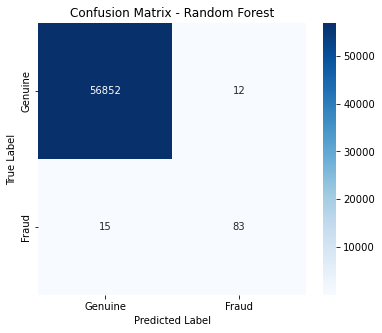

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [29]:
# ROC curve

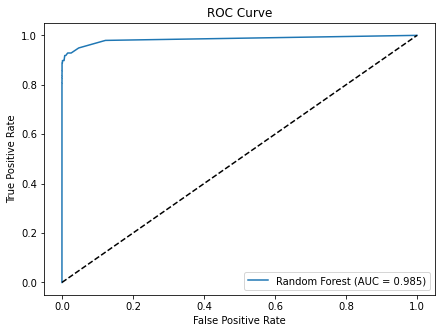

In [30]:
from sklearn.metrics import roc_curve, auc
rf_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.3f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [31]:
# Feature Importance

In [32]:
import pandas as pd

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)




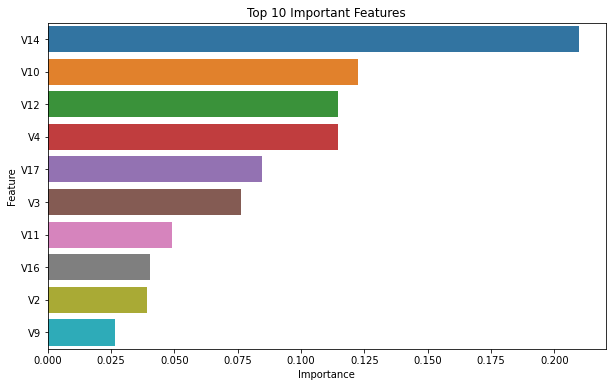

In [33]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

# Conclusion

Three machine learning models were trained and evaluated.

Random Forest achieved the best balance between Accuracy, Precision, Recall and F1-Score.

Therefore Random Forest was selected as the final model.

In [34]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(rf_model, "../models/fraud_detection_model.pkl")

print("Model Saved Successfully")


Model Saved Successfully
